In [7]:
import numpy as np
import tensorflow as tf
import seaborn as sns
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [8]:
training_datagen = ImageDataGenerator(
    rescale = 1./255,
    zoom_range=0.2,
    shear_range=0.2,
    horizontal_flip=True
)

print(training_datagen)

training_set = training_datagen.flow_from_directory(
    './dataset/train',
    target_size = (128,128),
    batch_size = 32,
    subset = 'training',
    class_mode = 'categorical',
)

print(training_set.class_indices)

Found 1494 images belonging to 5 classes.
{'acne': 0, 'eksim': 1, 'herpes': 2, 'panu': 3, 'rosacea': 4}


In [9]:
testing_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

validation_set = testing_datagen.flow_from_directory(
    './dataset/train',
    target_size=(128,128),
    batch_size=32,
    subset='validation',
    class_mode='categorical',
    shuffle=False
)

print(validation_set.class_indices)


Found 298 images belonging to 5 classes.
{'acne': 0, 'eksim': 1, 'herpes': 2, 'panu': 3, 'rosacea': 4}


In [10]:
cnn = tf.keras.models.Sequential()

In [11]:
cnn.add(tf.keras.layers.Conv2D(filters=64, kernel_size=3, input_shape=[128,128,3]))
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2, strides=2))

d:\Anaconda\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [14]:
cnn.add(tf.keras.layers.Conv2D(filters=128, kernel_size=3))
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2, strides=2))

In [15]:
cnn.add(tf.keras.layers.Conv2D(filters=256, kernel_size=3))
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2, strides=2))

In [16]:
cnn.add(tf.keras.layers.Flatten())

In [17]:
cnn.add(tf.keras.layers.Dense(units=256, activation='relu'))

In [18]:
cnn.add(tf.keras.layers.Dense(units=5, activation='softmax'))

In [19]:
cnn.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [21]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stop = EarlyStopping(
    monitor='val_loss',        # watch validation loss
    patience=5,                # wait 5 epochs before stopping
    restore_best_weights=True, 
    verbose=1
)

checkpoint = ModelCheckpoint(
    'best_skin_model.h5',      # file name
    monitor='val_loss',
    save_best_only=True,       # only save when better
    mode='min',
    verbose=1
)


In [22]:
cnn_model = cnn.fit(x = training_set, validation_data=validation_set, epochs=50, callbacks=[early_stop,checkpoint])

Epoch 1/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 924ms/step - accuracy: 0.2279 - loss: 1.7117
Epoch 1: val_loss improved from None to 1.42065, saving model to best_skin_model.h5


47/47 ━━━━━━━━━━━━━━━━━━━━ 57s 979ms/step - accuracy: 0.2651 - loss: 1.6166 - val_accuracy: 0.4463 - val_loss: 1.4207
Epoch 2/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 409ms/step - accuracy: 0.3901 - loss: 1.3783
Epoch 2: val_loss improved from 1.42065 to 1.39034, saving model to best_skin_model.h5


47/47 ━━━━━━━━━━━━━━━━━━━━ 21s 440ms/step - accuracy: 0.4090 - loss: 1.3673 - val_accuracy: 0.4597 - val_loss: 1.3903
Epoch 3/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 562ms/step - accuracy: 0.4315 - loss: 1.2965
Epoch 3: val_loss improved from 1.39034 to 1.03740, saving model to best_skin_model.h5


47/47 ━━━━━━━━━━━━━━━━━━━━ 28s 590ms/step - accuracy: 0.4652 - loss: 1.2353 - val_accuracy: 0.5570 - val_loss: 1.0374
Epoch 4/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 464ms/step - accuracy: 0.5328 - loss: 1.1343
Epoch 4: val_loss did not improve from 1.03740
47/47 ━━━━━━━━━━━━━━━━━━━━ 23s 488ms/step - accuracy: 0.5274 - loss: 1.1573 - val_accuracy: 0.4027 - val_loss: 1.5117
Epoch 5/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 415ms/step - accuracy: 0.4663 - loss: 1.2533
Epoch 5: val_loss improved from 1.03740 to 0.97840, saving model to best_skin_model.h5


47/47 ━━━━━━━━━━━━━━━━━━━━ 21s 441ms/step - accuracy: 0.5154 - loss: 1.1765 - val_accuracy: 0.6242 - val_loss: 0.9784
Epoch 6/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 407ms/step - accuracy: 0.5687 - loss: 1.0343
Epoch 6: val_loss did not improve from 0.97840
47/47 ━━━━━━━━━━━━━━━━━━━━ 21s 435ms/step - accuracy: 0.5817 - loss: 1.0135 - val_accuracy: 0.5940 - val_loss: 1.1088
Epoch 7/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 397ms/step - accuracy: 0.5715 - loss: 1.0307
Epoch 7: val_loss improved from 0.97840 to 0.81134, saving model to best_skin_model.h5


...

47/47 ━━━━━━━━━━━━━━━━━━━━ 19s 411ms/step - accuracy: 0.9063 - loss: 0.2654 - val_accuracy: 0.9597 - val_loss: 0.1335
Epoch 22/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 366ms/step - accuracy: 0.8938 - loss: 0.2756
Epoch 22: val_loss did not improve from 0.13346
47/47 ━━━━━━━━━━━━━━━━━━━━ 18s 387ms/step - accuracy: 0.8762 - loss: 0.3369 - val_accuracy: 0.9396 - val_loss: 0.1502
Epoch 23/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 358ms/step - accuracy: 0.9358 - loss: 0.1916
Epoch 23: val_loss improved from 0.13346 to 0.08943, saving model to best_skin_model.h5


47/47 ━━━━━━━━━━━━━━━━━━━━ 18s 382ms/step - accuracy: 0.9404 - loss: 0.1705 - val_accuracy: 0.9664 - val_loss: 0.0894
Epoch 24/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 432ms/step - accuracy: 0.9300 - loss: 0.1969
Epoch 24: val_loss did not improve from 0.08943
47/47 ━━━━━━━━━━━━━━━━━━━━ 22s 465ms/step - accuracy: 0.9177 - loss: 0.2441 - val_accuracy: 0.9564 - val_loss: 0.1500
Epoch 25/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 488ms/step - accuracy: 0.9304 - loss: 0.2078
Epoch 25: val_loss did not improve from 0.08943
47/47 ━━━━━━━━━━━━━━━━━━━━ 24s 517ms/step - accuracy: 0.9290 - loss: 0.2058 - val_accuracy: 0.9631 - val_loss: 0.1212
Epoch 26/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 483ms/step - accuracy: 0.9462 - loss: 0.1823
Epoch 26: val_loss improved from 0.08943 to 0.07560, saving model to best_skin_model.h5


47/47 ━━━━━━━━━━━━━━━━━━━━ 24s 512ms/step - accuracy: 0.9444 - loss: 0.1775 - val_accuracy: 0.9832 - val_loss: 0.0756
Epoch 27/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 380ms/step - accuracy: 0.9590 - loss: 0.1296
Epoch 27: val_loss improved from 0.07560 to 0.06001, saving model to best_skin_model.h5


47/47 ━━━━━━━━━━━━━━━━━━━━ 19s 405ms/step - accuracy: 0.9585 - loss: 0.1406 - val_accuracy: 0.9832 - val_loss: 0.0600
Epoch 28/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 354ms/step - accuracy: 0.9546 - loss: 0.1180
Epoch 28: val_loss improved from 0.06001 to 0.02956, saving model to best_skin_model.h5


47/47 ━━━━━━━━━━━━━━━━━━━━ 18s 377ms/step - accuracy: 0.9625 - loss: 0.0985 - val_accuracy: 0.9899 - val_loss: 0.0296
Epoch 29/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 365ms/step - accuracy: 0.9415 - loss: 0.1756
Epoch 29: val_loss did not improve from 0.02956
47/47 ━━━━━━━━━━━━━━━━━━━━ 18s 387ms/step - accuracy: 0.9250 - loss: 0.2188 - val_accuracy: 0.9597 - val_loss: 0.1052
Epoch 30/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 384ms/step - accuracy: 0.9189 - loss: 0.2638
Epoch 30: val_loss did not improve from 0.02956
47/47 ━━━━━━━━━━━━━━━━━━━━ 19s 412ms/step - accuracy: 0.9170 - loss: 0.2739 - val_accuracy: 0.9664 - val_loss: 0.0798
Epoch 31/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 510ms/step - accuracy: 0.9322 - loss: 0.1937
Epoch 31: val_loss did not improve from 0.02956
47/47 ━━━━━━━━━━━━━━━━━━━━ 25s 541ms/step - accuracy: 0.9270 - loss: 0.2066 - val_accuracy: 0.9664 - val_loss: 0.0875
Epoch 32/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 471ms/step - accuracy: 0.9510 - loss: 0.1496
Epoch 32: val_loss did not improve f

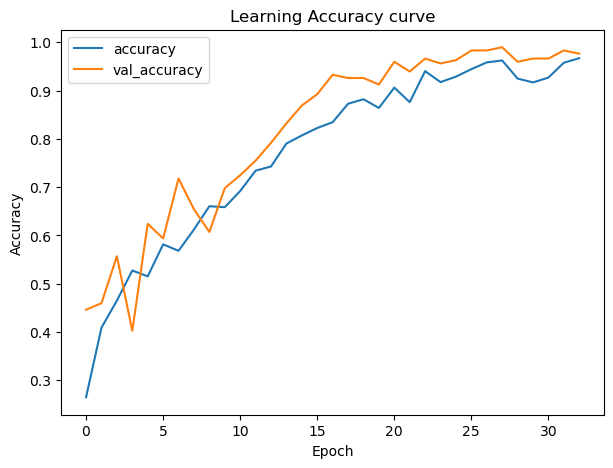

In [23]:
plt.figure(figsize=(7,5))
plt.title('Learning Accuracy curve')
plt.plot(cnn_model.history['accuracy'], label='accuracy')
plt.plot(cnn_model.history['val_accuracy'], label='val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

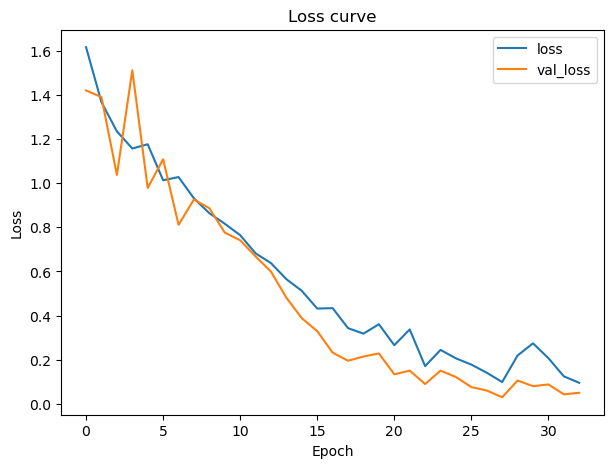

In [24]:
plt.figure(figsize=(7,5))
plt.title('Loss curve')
plt.plot(cnn_model.history['loss'], label='loss')
plt.plot(cnn_model.history['val_loss'], label='val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [25]:
y_pred = cnn.predict(validation_set)

10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 132ms/step


10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 100ms/step


<Axes: >

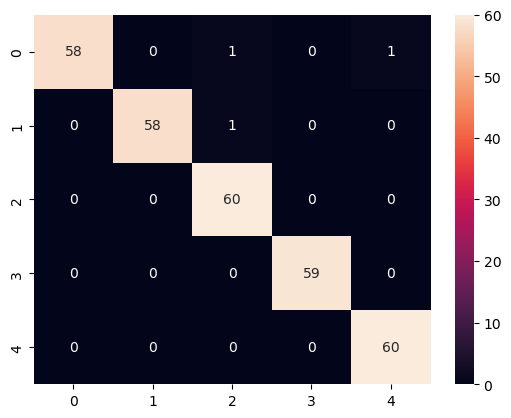

In [30]:
from sklearn.metrics import confusion_matrix
import numpy as np

# True labels
y_true = validation_set.classes

# Predicted probabilities
y_pred = cnn.predict(validation_set)

# Convert to class index
y_pred = np.argmax(y_pred, axis=1)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

sns.heatmap(cm, annot=True)

In [31]:
from sklearn.metrics import classification_report
print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.97      0.98        60
           1       1.00      0.98      0.99        59
           2       0.97      1.00      0.98        60
           3       1.00      1.00      1.00        59
           4       0.98      1.00      0.99        60

    accuracy                           0.99       298
   macro avg       0.99      0.99      0.99       298
weighted avg       0.99      0.99      0.99       298



In [32]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_true, y_pred) * 100
print(f"The Accuracy of the model is: {round(accuracy,2)}%")

The Accuracy of the model is: 98.99%
